In [ ]:
# mount the data from google drive
from google.colab import drive
from google.colab import files
drive.mount("/content/drive")

# navigate to the project folder
%cd drive/MyDrive/projects/CVPR

Mounted at /content/drive
/content/drive/MyDrive/projects/CVPR


In [ ]:
ls ms-coco/

coco_ann2017.zip            coco_train2017.zip  depth/          json-files/
coco-freeview-fixation.csv  coco_val2017.zip    fixations/      old-coco/
coco-images/                deepgaze/           images-by-cat/  stuffthingmaps_trainval2017.zip


In [ ]:
!pip install git+https://github.com/matthias-k/DeepGaze.git
!pip install pysaliency


  Cloning https://github.com/matthias-k/DeepGaze.git to /tmp/pip-req-build-5r0qn7xo
  Running command git clone --filter=blob:none --quiet https://github.com/matthias-k/DeepGaze.git /tmp/pip-req-build-5r0qn7xo
  Resolved https://github.com/matthias-k/DeepGaze.git to commit 874f12e1ee519860f49860638cf7f6375956d45a
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.6 MB/s eta 0:00:00
   

In [ ]:
#################### example code chunk from github
# https://github.com/matthias-k/DeepGaze
######################
import numpy as np
from scipy.misc import face
from scipy.ndimage import zoom
from scipy.special import logsumexp
import torch

import deepgaze_pytorch

DEVICE = 'cuda'

# you can use DeepGazeI or DeepGazeIIE
model = deepgaze_pytorch.DeepGazeIIE(pretrained=True).to(DEVICE)

image = face()

# load precomputed centerbias log density (from MIT1003) over a 1024x1024 image
# you can download the centerbias from https://github.com/matthias-k/DeepGaze/releases/download/v1.0.0/centerbias_mit1003.npy
# alternatively, you can use a uniform centerbias via `centerbias_template = np.zeros((1024, 1024))`.
centerbias_template = np.load('centerbias_mit1003.npy')
# rescale to match image size
centerbias = zoom(centerbias_template, (image.shape[0]/centerbias_template.shape[0], image.shape[1]/centerbias_template.shape[1]), order=0, mode='nearest')
# renormalize log density
centerbias -= logsumexp(centerbias)

image_tensor = torch.tensor([image.transpose(2, 0, 1)]).to(DEVICE)
centerbias_tensor = torch.tensor([centerbias]).to(DEVICE)

log_density_prediction = model(image_tensor, centerbias_tensor)

In [ ]:

############################# what is currently in the paper
import numpy as np
import torch
import gc
from scipy.ndimage import zoom
from scipy.special import logsumexp
from PIL import Image
import deepgaze_pytorch
import os

def list_files(path):
    """Lists all files in the specified directory."""
    return [entry[:-4] for entry in os.listdir(path) if os.path.isfile(os.path.join(path, entry))]

def resize_image(image_path, scale=0.3):
    """Resizes image to reduce memory usage."""
    image = Image.open(image_path).convert("RGB")  # Ensure 3-channel RGB
    new_size = (int(image.width * scale), int(image.height * scale))
    return np.asarray(image.resize(new_size, Image.LANCZOS))

# Load model **once** outside the loop
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model = deepgaze_pytorch.DeepGazeIIE(pretrained=True).to(DEVICE).half()
model.eval()  # Use inference mode to reduce memory

# Load centerbias template **once**  ---> this is where you need to change it to the deepgaze center bias
centerbias_template = np.zeros((350, 560))

### for zoe
### deep gaze center bias
# check the code chunk above to see how to get it to work
# centerbias_template = np.load('centerbias_mit1003.npy')


# Grab image list from drive
img_dir = "ms-coco/coco-images/"
image_paths = list_files(img_dir)

# Process images
for image_path in image_paths:
    print(image_path)
    image = resize_image(os.path.join(img_dir, image_path + ".jpg"))

    # Resize centerbias to match image
    centerbias = zoom(
        centerbias_template,
        (image.shape[0] / centerbias_template.shape[0], image.shape[1] / centerbias_template.shape[1]),
        order=0,
        mode="nearest",
    )
    centerbias -= logsumexp(centerbias)  # Renormalize log density

    # Convert to PyTorch tensors **in float16 to reduce memory**
    image_tensor = torch.tensor([image.transpose(2, 0, 1)], dtype=torch.float16).to(DEVICE)
    centerbias_tensor = torch.tensor([centerbias], dtype=torch.float16).to(DEVICE)

    # Disable gradient tracking to save memory
    with torch.no_grad():
        log_density_prediction = model(image_tensor, centerbias_tensor)

    # Save output
    np.save(f"/content/drive/MyDrive/projects/CVPR/ms-coco/deepgaze/{image_path}.npy", log_density_prediction.cpu().numpy()[0, 0])

    # Free memory
    del image, centerbias, image_tensor, centerbias_tensor, log_density_prediction
    torch.cuda.empty_cache()
    gc.collect()  # Force garbage collection


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Downloading: "https://bitbucket.org/robert_geirhos/texture-vs-shape-pretrained-models/raw/60b770e128fffcbd8562a3ab3546c1a735432d03/resnet50_finetune_60_epochs_lr_decay_after_30_start_resnet50_train_45_epochs_combined_IN_SF-ca06340c.pth.tar" to /root/.cache/torch/hub/checkpoints/resnet50_finetune_60_epochs_lr_decay_after_30_start_resnet50_train_45_epochs_combined_IN_SF-ca06340c.pth.tar
100%|██████████| 195M/195M [00:12<00:00, 16.5MB/s]
Downloading: "https://github.com/lukemelas/Efficient

Loaded pretrained weights for efficientnet-b5


Downloading: "https://github.com/pytorch/vision/zipball/v0.6.0" to /root/.cache/torch/hub/v0.6.0.zip
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet201_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet201_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth
100%|██████████| 77.4M/77.4M [00:00<00:00, 208MB/s]
Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.6.0
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equ

000000205560


<ipython-input-5-768db501f393>:47: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  image_tensor = torch.tensor([image.transpose(2, 0, 1)], dtype=torch.float16).to(DEVICE)


000000560748
000000510456
000000260519
000000043375
000000153832
000000431818
000000141278
000000438835
000000002024
000000036639
000000425359
000000140821
000000055627
000000353495
000000452861
000000080397
000000382559
000000217720
000000256611
000000499134
000000040988
000000366527
000000306030
000000515670
000000422866
000000422172
000000460312
000000390693
000000227069
000000401556
000000564629
000000368349
000000218343
000000363190
000000147778
000000452272
000000085459
000000400347
000000219687
000000306313
000000405141
000000329613
000000199354
000000030401
000000324334
000000418113
000000264018
000000039963
000000128254
000000104326
000000577107
000000434127
000000184903
000000511024
000000302710
000000274017
000000227540
000000398842
000000402368
000000315637
000000082858
000000266209
000000299411
000000241599
000000409821
000000561894
000000488345
000000024845
000000096183
000000071769
000000088759
000000142485
000000031286
000000486383
000000390073
000000475744
000000021020

NameError: name 'image' is not defined

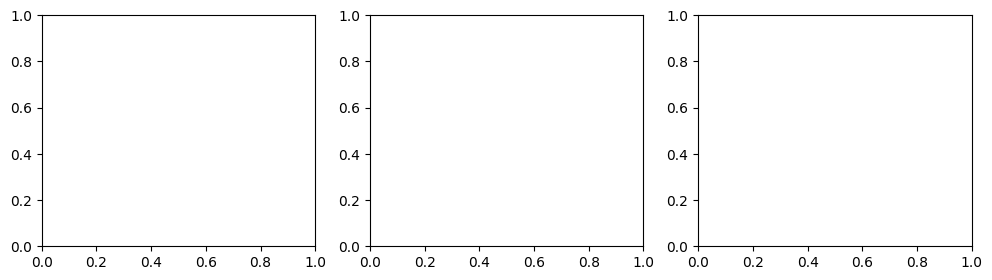

In [ ]:
import matplotlib.pyplot as plt
from pysaliency.plotting import visualize_distribution

f, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 3))
axs[0].imshow(image)
axs[0].set_axis_off()
axs[1].matshow(log_density_prediction.detach().cpu().numpy()[0, 0])  # first image in batch, first (and only) channel
axs[1].set_axis_off()
visualize_distribution(log_density_prediction.detach().cpu().numpy()[0, 0], ax=axs[2])
axs[2].set_axis_off()